In [1]:
from dataclasses import dataclass
from typing import Dict, List, Optional, Sequence, Tuple
import yfinance as yf
import numpy as np
import pandas as pd
import torch
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import math

In [2]:
DEFAULT_FEATURE_COLUMNS = ["open", "high", "low", "close", "volume"]

def download_stock_data(
    ticker: str = "AAPL",
    period: str = "3y",
    interval: str = "1d",
) -> pd.DataFrame:
    """
    Download OHLCV data with yfinance and reshape it for the training pipeline.

    Returned columns:
    open, high, low, close, volume
    """

    data = yf.download(ticker, period=period, interval=interval, auto_adjust=True, progress=False)
    if data.empty:
        raise ValueError(f"No data returned for ticker={ticker}, period={period}, interval={interval}.")

    # yfinance may return a MultiIndex for columns depending on version and parameters.
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)

    data = data.rename(
        columns={
            "Open": "open",
            "High": "high",
            "Low": "low",
            "Close": "close",
            "Volume": "volume",
        }
    )

    cleaned = data[DEFAULT_FEATURE_COLUMNS].copy()
    cleaned = cleaned.dropna().reset_index(drop=True)

    if len(cleaned) <= 20:
        raise ValueError("Downloaded dataset is too small for lookback-based training.")

    return cleaned

In [3]:
class StockSequenceDataset(Dataset):
    """Dataset of windowed features and multi-step targets."""

    def __init__(self, X: np.ndarray, y: np.ndarray) -> None:
        self.X = torch.as_tensor(X, dtype=torch.float32)
        self.y = torch.as_tensor(y, dtype=torch.float32)

    def __len__(self) -> int:
        return len(self.X)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        return self.X[idx], self.y[idx]


def create_sequences(
    X: np.ndarray,
    y: np.ndarray,
    lookback: int,
    horizon: int
) -> Tuple[np.ndarray, np.ndarray]:
    """Convert flat arrays into sliding windows."""
    X_seq, y_seq = [], []

    for end_idx in range(lookback, len(X) - horizon + 1):
        start_idx = end_idx - lookback
        X_seq.append(X[start_idx:end_idx])
        y_seq.append(y[end_idx:end_idx + horizon].reshape(-1))

    return np.asarray(X_seq, dtype=np.float32), np.asarray(y_seq, dtype=np.float32)


def compute_returns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Convert raw OHLCV into return-based features plus volatility context.

    Features:
      open_ret … volume_ret — % changes vs previous bar
      atr_pct   — EWM of true range / previous close (scale-free volatility)
      rv_ewm    — EWM std of close_ret (short-horizon realized vol)

    Target:
      close_ret
    """
    out = df[["open", "high", "low", "close", "volume"]].pct_change().copy()
    out.columns = ["open_ret", "high_ret", "low_ret", "close_ret", "volume_ret"]

    prev_close = df["close"].shift(1)
    tr = pd.concat(
        [
            df["high"] - df["low"],
            (df["high"] - prev_close).abs(),
            (df["low"] - prev_close).abs(),
        ],
        axis=1,
    ).max(axis=1)
    out["atr_pct"] = (tr / prev_close).ewm(span=14, adjust=False).mean()
    out["rv_ewm"] = out["close_ret"].ewm(span=20, adjust=False).std()

    return out.dropna()


VOL_FEATURES = ("atr_pct", "rv_ewm")


def prepare_datasets(
    df: pd.DataFrame,
    feature_columns: List[str] = None,
    target_column: str = "close_ret",
    lookback: int = 20,
    horizon: int = 5,
    batch_size: int = 64,
) -> Dict[str, object]:

    returns_df = compute_returns(df)
    feature_columns = feature_columns or [
        "open_ret", "high_ret", "low_ret", "close_ret", "volume_ret",
        *VOL_FEATURES,
    ]

    returns_df = returns_df.dropna().copy()

    n         = len(returns_df)
    train_end = int(n * 0.70)
    val_end   = int(n * 0.85)

    # overlapping dataset (lucas)
    train_df = returns_df.iloc[:train_end].copy()
    val_df   = returns_df.iloc[train_end - lookback : val_end].copy()
    test_df  = returns_df.iloc[val_end  - lookback :].copy()

    # Z-score volatility features on train stats only (avoid leakage)
    for c in VOL_FEATURES:
        mu = train_df[c].mean()
        sig = train_df[c].std() + 1e-8
        train_df[c] = (train_df[c] - mu) / sig
        val_df[c] = (val_df[c] - mu) / sig
        test_df[c] = (test_df[c] - mu) / sig

    def transform(df_part):
        X = df_part[feature_columns].values.astype(np.float32)
        y = df_part[[target_column]].values.astype(np.float32)
        return create_sequences(X, y, lookback, horizon)

    train_X, train_y = transform(train_df)
    val_X,   val_y   = transform(val_df)
    test_X,  test_y  = transform(test_df)

    dataloaders = {
        "train": DataLoader(StockSequenceDataset(train_X, train_y),
                            batch_size=batch_size, shuffle=False,
                            drop_last=True, num_workers=0),
        "val":   DataLoader(StockSequenceDataset(val_X, val_y),
                            batch_size=batch_size, shuffle=False),
        "test":  DataLoader(StockSequenceDataset(test_X, test_y),
                            batch_size=batch_size, shuffle=False),
    }

    return {
        "dataloaders": dataloaders,
        "train_df":    train_df,
        "val_df":      val_df,
        "test_df":     test_df,
        "returns_df":  returns_df,
    }

In [4]:

df = download_stock_data(ticker="TSLA", period="3y", interval="1d")

prepared = prepare_datasets(df, batch_size = 32)


In [5]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.pe[:, :x.size(1)]

class TimeSeriesTransformer(nn.Module):
    def __init__(self, input_dim: int, d_model: int = 64, nhead: int = 4, num_layers: int = 3, dropout: float = 0.2, horizon: int = 5, dim_feedforward: int = 256):
        super().__init__()
        self.model_type = 'Transformer'
        self.pos_encoder = PositionalEncoding(d_model)
        self.encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dropout=dropout, batch_first=True, dim_feedforward=dim_feedforward)
        self.transformer_encoder = nn.TransformerEncoder(self.encoder_layer, num_layers=num_layers)
        self.input_linear = nn.Linear(input_dim, d_model)
        self.decoder = nn.Linear(d_model, horizon)
        self.d_model = d_model
        self.horizon = horizon

    def forward(self, src: torch.Tensor) -> torch.Tensor:
        src = self.input_linear(src) * math.sqrt(self.d_model)
        src = self.pos_encoder(src)
        output = self.transformer_encoder(src)
        output = self.decoder(output[:, -1, :])
        return output

In [6]:
print(torch.version.cuda)

12.8


In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Ensure model and data are initialized
model = TimeSeriesTransformer(input_dim=7, horizon=5).to(device)
print(model)
# print(f'Model initialized with d_model={model.d_model}')
train_loader = prepared['dataloaders']['train']
val_loader = prepared['dataloaders']['val']

print("Number of samples:", len(train_loader.dataset))
print("Number of batches:", len(train_loader))

batch_X, batch_y = next(iter(train_loader))

print("=== Data Sanity Check ===")
print(f"X shape       : {batch_X.shape}")          # expect (batch, lookback, 7)
print(f"y shape       : {batch_y.shape}")          # expect (64, 5)
print(f"X mean / std  : {batch_X.mean():.4f} / {batch_X.std():.4f}")   # expect ~0 / ~1
print(f"y mean / std  : {batch_y.mean():.4f} / {batch_y.std():.4f}")   # expect ~0 / ~1
print(f"X has NaN     : {torch.isnan(batch_X).any()}")
print(f"y has NaN     : {torch.isnan(batch_y).any()}")
print(f"y range       : [{batch_y.min():.4f}, {batch_y.max():.4f}]")
print(f"Sample y[0]   : {batch_y[0]}")

Using device: cuda
TimeSeriesTransformer(
  (pos_encoder): PositionalEncoding()
  (encoder_layer): TransformerEncoderLayer(
    (self_attn): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
    )
    (linear1): Linear(in_features=64, out_features=256, bias=True)
    (dropout): Dropout(p=0.2, inplace=False)
    (linear2): Linear(in_features=256, out_features=64, bias=True)
    (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (dropout1): Dropout(p=0.2, inplace=False)
    (dropout2): Dropout(p=0.2, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)

# Loss Function?

In [8]:
class StockReturnLoss(nn.Module):
    """MSE + batch std match + direction (wrong-sign penalty + hinge margin on sign)."""

    def __init__(self, var_weight=1.0, dir_weight=0.3, hinge_scale=0.5, debug=False):
        super().__init__()
        self.var_weight = var_weight
        self.dir_weight = dir_weight
        self.hinge_scale = hinge_scale
        self.last_mse = 0
        self.last_var = 0
        self.last_dir = 0

    def forward(self, pred, target):
        mse = F.mse_loss(pred, target)

        pred_std = pred.std(dim=0).mean()
        target_std = target.std(dim=0).mean()
        std_penalty = (pred_std - target_std).pow(2)

        wrong_direction = torch.relu(-pred * target)
        mask = target != 0
        if mask.any():
            s = torch.sign(target)
            dir_hinge = torch.relu(1.0 - pred * s)
            dir_hinge = (dir_hinge * mask.float()).sum() / mask.float().sum().clamp(min=1.0)
        else:
            dir_hinge = pred.new_tensor(0.0)
        dir_penalty = wrong_direction.mean() + self.hinge_scale * dir_hinge

        self.last_mse = mse.item()
        self.last_var = std_penalty.item()
        self.last_dir = dir_penalty.item()

        return mse + self.var_weight * std_penalty + self.dir_weight * dir_penalty

In [9]:
# --- Configuration ---
num_epochs    = 500
learning_rate = 0.001

# Emphasize directional fit vs std matching (tunable)
criterion = StockReturnLoss(var_weight=3.0, dir_weight=2.0, hinge_scale=0.5)
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=10,
              factor=0.5, min_lr=1e-6)


def directional_accuracy(pred: torch.Tensor, target: torch.Tensor) -> float:
    """Fraction of entries where pred and target have the same sign (zero targets skipped)."""
    mask = target != 0
    if mask.sum().item() == 0:
        return float("nan")
    return (torch.sign(pred[mask]) == torch.sign(target[mask])).float().mean().item()


# --- Sample Data Preview ---
batch_X, batch_y = next(iter(train_loader))
print("--- Sample Data from Loaders ---")
print(f"X shape: {batch_X.shape} | y shape: {batch_y.shape}")
print(f"Sample X[0]:\n{batch_X[0]}\n")
print(f"Sample y[0]:\n{batch_y[0]}\n")

# --- Training Loop ---
for epoch in range(num_epochs):

    # ── Train ─────────────────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0
    for batch_idx, (batch_X, batch_y) in enumerate(train_loader):
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(batch_X)
        loss    = criterion(outputs, batch_y)   # returns single scalar now
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * batch_X.size(0)

    # ── Validate ──────────────────────────────────────────────────────────────
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_idx, (batch_X, batch_y) in enumerate(val_loader):
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs  = model(batch_X)
            loss     = criterion(outputs, batch_y)
            val_loss += loss.item() * batch_X.size(0)

            if batch_idx == 0:
                sample_val_preds = outputs.detach().cpu()
                sample_val_true  = batch_y.detach().cpu()

    train_loss /= len(train_loader.dataset)
    val_loss   /= len(val_loader.dataset)
    scheduler.step(val_loss)

    # ── Logging ───────────────────────────────────────────────────────────────
    if (epoch + 1) % 10 == 0:
        pred_std   = sample_val_preds.std().item()
        true_std   = sample_val_true.std().item()
        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch [{epoch+1:>3}/{num_epochs}] "
            f"| Train: {train_loss:.6f} "
            f"| Val: {val_loss:.6f} "
            f"| pred_std: {pred_std:.5f} "
            f"| true_std: {true_std:.5f} "
            f"| mse: {criterion.last_mse:.6f} "
            f"| var_p: {criterion.last_var:.6f} "
            f"| dir_p: {criterion.last_dir:.6f} "
            f"| LR: {current_lr:.2e}"
        )

print("Training complete!")



--- Sample Data from Loaders ---
X shape: torch.Size([32, 20, 7]) | y shape: torch.Size([32, 5])
Sample X[0]:
tensor([[-3.4462e-02, -4.0556e-02, -3.4468e-02, -3.6660e-02,  5.8663e-02,
         -4.3395e-01, -1.4946e+00],
        [-3.9051e-02, -2.2498e-02, -2.1876e-02, -2.4796e-03, -7.4876e-02,
         -5.1377e-01, -1.8193e+00],
        [-1.7151e-02, -6.9209e-03, -2.0196e-02, -2.9720e-03,  1.4772e-01,
         -4.5142e-01, -1.9667e+00],
        [ 3.7513e-02,  2.2096e-02,  5.4171e-02,  1.2357e-02, -1.8560e-01,
         -6.3718e-01, -1.7921e+00],
        [ 2.1694e-02,  1.2633e-02, -2.8764e-02, -3.3460e-02,  2.9788e-01,
         -4.3693e-01, -1.6844e+00],
        [-4.0789e-02, -2.6516e-02,  3.4940e-03,  2.9689e-02, -2.4840e-01,
         -5.4563e-01, -1.2860e+00],
        [ 5.4110e-03, -1.1796e-03,  5.9135e-03, -4.8413e-03, -1.4605e-01,
         -7.4357e-01, -1.4236e+00],
        [ 1.2884e-02,  1.8306e-02,  3.7361e-03,  1.1027e-02,  2.0970e-01,
         -7.6153e-01, -1.4517e+00],
        [ 

In [10]:
test_loader = prepared["dataloaders"]["test"]
model.eval()
preds, trues = [], []
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        out = model(batch_X)
        preds.append(out.cpu())
        trues.append(batch_y)
pred_all = torch.cat(preds, dim=0)
true_all = torch.cat(trues, dim=0)
print(f"Overall directional accuracy (test): {directional_accuracy(pred_all, true_all):.4f}")

Overall directional accuracy (test): 0.5009


Predicted % returns : [0.01893024 0.05249398 0.04482804 0.06137074 0.02379848]
Actual    % returns : [ 0.01796997  0.00208451 -0.0463912   0.03740057  0.02586735]

Last known close         : 452.42
Predicted next 5 closes  : [460.9844133  485.18330048 506.93310518 538.04394921 550.8485894 ]
Reconstructed actuals    : [460.54998566 461.50998715 440.09998523 456.55999292 468.37000684]
True actuals from df     : [460.54998779 461.51000977 440.1000061  456.55999756 468.36999512]


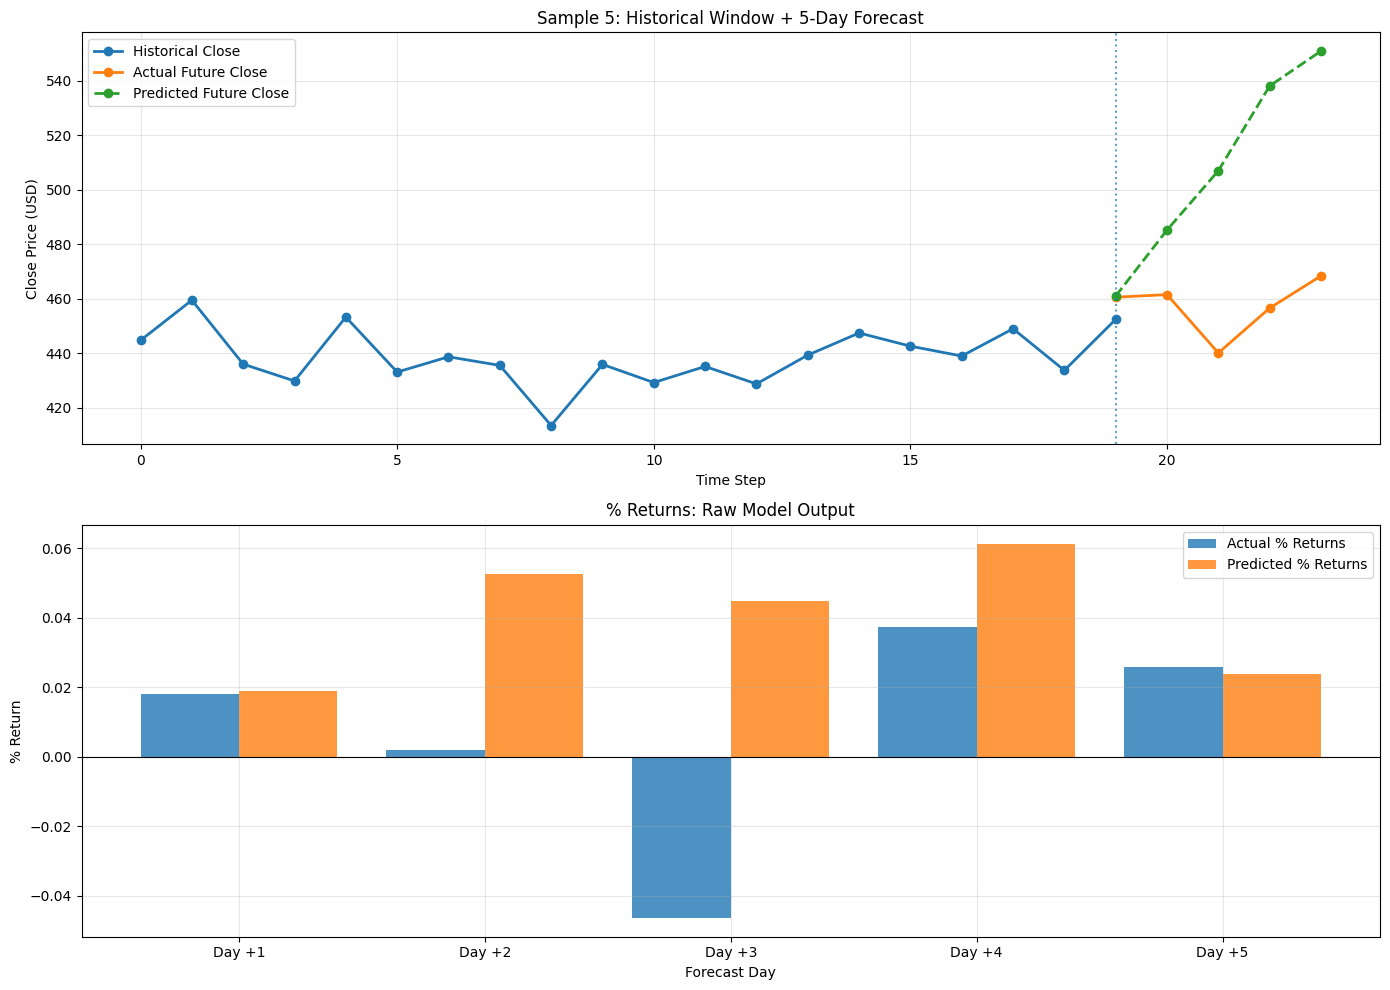

In [11]:
model.eval()

test_dataset = prepared["dataloaders"]["test"].dataset
test_df      = prepared["test_df"]

lookback   = 20
horizon    = 5
sample_idx = 5

# ── 1. Run inference ──────────────────────────────────────────────────────────
single_X, single_y = test_dataset[sample_idx]
single_X = single_X.unsqueeze(0).to(device)

with torch.no_grad():
    pred_returns = model(single_X).cpu().numpy().flatten()    # shape: (5,)
actual_returns = single_y.numpy().flatten()                   # shape: (5,)

print(f"Predicted % returns : {pred_returns}")
print(f"Actual    % returns : {actual_returns}")

# ── 2. Reconstruct prices from last known close ───────────────────────────────
# returns_df dropped row 0 via pct_change, so returns_df.iloc[i] == df.iloc[i+1]
# test_df starts at returns_df.iloc[val_end - lookback]
val_end = int((len(df) - 1) * 0.85)

last_close_idx      = val_end + sample_idx
last_close          = df["close"].iloc[last_close_idx]
actual_future_close = df["close"].iloc[last_close_idx + 1 : last_close_idx + 1 + horizon].values

# chain-multiply: price_t = last_close × (1+r1) × (1+r2) × ...
pred_prices   = last_close * np.cumprod(1 + pred_returns)
actual_prices = last_close * np.cumprod(1 + actual_returns)

print(f"\nLast known close         : {last_close:.2f}")
print(f"Predicted next 5 closes  : {pred_prices}")
print(f"Reconstructed actuals    : {actual_prices}")
print(f"True actuals from df     : {actual_future_close}")   # sanity check

# ── 3. Historical window ──────────────────────────────────────────────────────
history_close = df["close"].iloc[last_close_idx - lookback + 1 : last_close_idx + 1].values

history_x = np.arange(lookback)
future_x  = np.arange(lookback - 1, lookback - 1 + horizon)

# ── 4. Plot ───────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# --- top: reconstructed prices ---
ax1.plot(history_x, history_close,       marker="o", linewidth=2, label="Historical Close")
ax1.plot(future_x,  actual_future_close, marker="o", linewidth=2, label="Actual Future Close")
ax1.plot(future_x,  pred_prices,         marker="o", linewidth=2, linestyle="--", label="Predicted Future Close")
ax1.axvline(x=lookback - 1, linestyle=":", alpha=0.7)
ax1.set_title(f"Sample {sample_idx}: Historical Window + 5-Day Forecast")
ax1.set_xlabel("Time Step")
ax1.set_ylabel("Close Price (USD)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- bottom: raw % returns ---
return_x = np.arange(horizon)
ax2.bar(return_x - 0.2, actual_returns, width=0.4, label="Actual % Returns",    alpha=0.8)
ax2.bar(return_x + 0.2, pred_returns,   width=0.4, label="Predicted % Returns", alpha=0.8)
ax2.axhline(y=0, color="black", linewidth=0.8)
ax2.set_title("% Returns: Raw Model Output")
ax2.set_xlabel("Forecast Day")
ax2.set_ylabel("% Return")
ax2.set_xticks(return_x)
ax2.set_xticklabels([f"Day +{i+1}" for i in return_x])
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()